# Scribble Conditioning Comparison

We compare four scribble conditioning strategies under a **neutral prompt**, measuring how well each matches a target distribution of 50% man / 50% woman portraits.

**Conditions**
- `man_scribble` — HED edge map extracted from a generated man portrait
- `woman_scribble` — HED edge map extracted from a generated woman portrait
- `avg_scribble` — pixel mean of the two HED maps
- `sdedit_scribble` — man scribble denoised toward a gender-neutral appearance via SDEdit

**Protocol (repeated over `N_RUNS` seeds)**
1. Generate source portraits → extract scribbles → run all four conditions.
2. Record MMD (CLIP space) vs a freshly drawn target distribution.
3. After all runs: for each method pick the **best scribble** (lowest MMD across seeds).
4. From that best scribble generate **2 000 images**, compute final MMD, and compute a 95 % CI for the proportion of male images (binomial, normal approximation).

## 1. Setup

In [1]:
import sys, os

if 'google.colab' in str(get_ipython()):
    !pip install -q diffusers transformers accelerate controlnet_aux scikit-learn peft

    from huggingface_hub import login
    from google.colab import userdata
    import getpass

    hf_token = userdata.get('HF') if hasattr(userdata, 'get') else None
    login(token=hf_token) if hf_token else login()

    github_token = userdata.get('GITHUB') if hasattr(userdata, 'get') else getpass.getpass('GitHub token: ')
    repo_url  = f'https://{github_token}@github.com/orineo1/conditional-matching-paper.git'
    repo_name = 'conditional-matching-paper'
    branch    = 'compareSDvsNaive'

    if not os.path.exists(repo_name):
        !git clone {repo_url}
    else:
        !cd {repo_name} && git pull
    !cd {repo_name} && git checkout {branch}

    for path in [f'/content/{repo_name}', f'/content/{repo_name}/SD_cond_SD_controlnet']:
        if path not in sys.path:
            sys.path.insert(0, path)

    print(f'Repo ready on branch: {branch}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 12.9 MB/s eta 0:00:00
Cloning into 'conditional-matching-paper'...
remote: Enumerating objects: 5638, done.
remote: Counting objects: 100% (388/388), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 5638 (delta 364), reused 285 (delta 279), pack-reused 5250 (from 3)
Receiving objects: 100% (5638/5638), 1.18 GiB | 40.86 MiB/s, done.
Resolving deltas: 100% (1503/1503), done.
error: pathspec 'compareSDvsNaive' did not match any file(s) known to git
Repo ready on branch: compareSDvsNaive


## 2. Imports

In [2]:
import copy, json
import numpy as np
import torch
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import norm
from IPython.display import display

from models        import load_models
from image_utils   import sobel_proxy, build_base_image
from clip_utils    import load_clip_model, encode_images_clip
from generation    import generate_and_store_cs
from run_dps       import compute_clip_softmax
from metrics       import compute_mmd

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda


## 3. Config

In [3]:
N_SOURCE         = 10     # portraits per gender used to extract scribbles each run
N_TARGET         = 2000   # target distribution size (50 % man / 50 % woman)
N_COND           = 250    # images per condition per seed (quick per-run MMD proxy)
N_FINAL          = 2000   # images from the best scribble for the final evaluation
N_RUNS           = 10
CONTROLNET_SCALE = 0.5
SDEDIT_START     = 125
N_STEPS          = 250
SDEDIT_CFG       = 7.5
SDEDIT_PROMPT = 'a face scribble sketch of man or woman'
MAN_PROMPT    = 'a superrealistic portrait photograph of a man, studio lighting'
WOMAN_PROMPT  = 'a superrealistic portrait photograph of a woman, studio lighting'
NEUTRAL_PROMPT = 'a superrealistic professional photograph of'

CONDITION_NAMES = ['man_scribble', 'woman_scribble', 'avg_scribble', 'sdedit_scribble']

print('Config OK')

Config OK


## 4. Load models

In [4]:
architect, sprinter    = load_models(device)
clip_model, clip_processor = load_clip_model(device)
print('Models loaded.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/2.50G [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded.


## 5. Helpers

In [5]:
from controlnet_aux import HEDdetector
hed = HEDdetector.from_pretrained('lllyasviel/Annotators')


def generate_and_store_cs(pipe, prompt, cond_pil, num_samples, batch_size=2, cn_scale=0.5, seed=None):
    """Generate images with ControlNet + collect latents."""
    original_vae_dtype = pipe.vae.dtype
    pipe.vae.to(dtype=torch.float16)
    all_images, all_lats = [], []

    def latents_callback(p, step_index, timestep, cb_kwargs):
        if step_index == p.num_timesteps - 1:
            p._current_latents = cb_kwargs['latents'].detach().cpu().numpy()
        return cb_kwargs

    generator = torch.Generator(device=pipe.device).manual_seed(seed) if seed is not None else None
    for i in range(0, num_samples, batch_size):
        curr = min(batch_size, num_samples - i)
        result = pipe(
            prompt=[prompt] * curr,
            image=[cond_pil] * curr,
            num_inference_steps=2,
            guidance_scale=0.0,
            controlnet_conditioning_scale=cn_scale,
            callback_on_step_end=latents_callback,
            generator=generator,
        )
        all_images.extend(result.images)
        all_lats.append(pipe._current_latents.reshape(curr, -1))
        print(f'  {len(all_images)}/{num_samples}', end='\r')
    print()
    pipe.vae.to(dtype=original_vae_dtype)
    return all_images, np.vstack(all_lats)


def generate_condition(scribble_pil, prompt, n, batch_size=2, seed=None):
    sprinter.vae.to(dtype=torch.float16)
    generator = torch.Generator(device=sprinter.device).manual_seed(seed) if seed is not None else None
    images = []
    with torch.no_grad():
        for start in range(0, n, batch_size):
            bs = min(batch_size, n - start)
            result = sprinter(
                prompt=[prompt] * bs,
                image=[scribble_pil] * bs,
                num_inference_steps=2,
                guidance_scale=0.0,
                controlnet_conditioning_scale=CONTROLNET_SCALE,
                output_type='pil',
                generator=generator,
            )
            images.extend(result.images)
            print(f'  {len(images)}/{n}', end='\r')
    sprinter.vae.to(dtype=torch.float32)
    print()
    return images


def clip_embed(images):
    """Encode a list of PIL images to CLIP embeddings."""
    tensors = torch.cat([TF.to_tensor(img).unsqueeze(0) for img in images]).to(device)
    clip_model.to(device)
    with torch.no_grad():
        embs = encode_images_clip(tensors, clip_model, clip_processor)
    clip_model.to('cpu')
    return embs


def build_target(sobel_pil, seed_offset=0, n=N_TARGET):
    n_half = n // 2
    with torch.no_grad():
        man_imgs, _   = generate_and_store_cs(sprinter, MAN_PROMPT,   sobel_pil, n_half, 2, CONTROLNET_SCALE, seed=seed_offset)
        woman_imgs, _ = generate_and_store_cs(sprinter, WOMAN_PROMPT, sobel_pil, n_half, 2, CONTROLNET_SCALE, seed=seed_offset + 500)
    return clip_embed(man_imgs + woman_imgs)


def run_sdedit(scr_man_pil, seed):
    """SDEdit: add noise to man scribble then denoise toward neutral prompt."""
    architect.vae.to(dtype=torch.float32)
    architect.scheduler.set_timesteps(N_STEPS, device=device)
    timesteps = architect.scheduler.timesteps

    with torch.no_grad():
        t = TF.to_tensor(scr_man_pil.convert('RGB')).unsqueeze(0).to(device).float()
        t = (t * 2.0) - 1.0
        latent = architect.vae.encode(t).latent_dist.mean * architect.vae.config.scaling_factor

    t_start = timesteps[SDEDIT_START]
    alpha   = architect.scheduler.alphas_cumprod.to(device)[t_start.long()].float()
    gen     = torch.Generator(device=device).manual_seed(seed)
    noise   = torch.randn(latent.shape, generator=gen, device=device, dtype=torch.float32)
    latents = ((alpha ** 0.5) * latent + ((1 - alpha) ** 0.5) * noise).half()

    with torch.no_grad():
        prompt_embeds, neg_embeds, pooled, neg_pooled = architect.encode_prompt(
            prompt=SDEDIT_PROMPT, negative_prompt='', device=device,
            do_classifier_free_guidance=True, num_images_per_prompt=1,
        )
    add_ids = torch.tensor([[512, 512, 0, 0, 512, 512]], dtype=prompt_embeds.dtype, device=device)
    added   = {'text_embeds': torch.cat([neg_pooled, pooled]), 'time_ids': add_ids.repeat(2, 1)}
    cfg_st  = torch.cat([neg_embeds, prompt_embeds])

    sched = copy.deepcopy(architect.scheduler)
    with torch.no_grad():
        for t in timesteps[SDEDIT_START:]:
            lmi  = sched.scale_model_input(torch.cat([latents] * 2), t)
            out  = architect.unet(lmi, t, encoder_hidden_states=cfg_st, added_cond_kwargs=added, return_dict=False)[0]
            nu, nc = out.chunk(2)
            latents = sched.step(nu + SDEDIT_CFG * (nc - nu), t, latents).prev_sample

    with torch.no_grad():
        dec = architect.vae.decode((latents.float() / architect.vae.config.scaling_factor).to(architect.vae.dtype)).sample
        pil = T.ToPILImage()(torch.clamp((dec.float() + 1.0) / 2.0, 0.0, 1.0).squeeze(0).cpu())
    return pil


def binomial_ci_normal(n_success, n_total, z=1.96):
    """Normal-approximation 95% CI for binomial proportion."""
    p_hat = n_success / n_total
    se    = np.sqrt(p_hat * (1 - p_hat) / n_total)
    return p_hat, p_hat - z * se, p_hat + z * se


print('Helpers ready.')

/usr/local/lib/python3.12/dist-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/controlnet_aux/segment_anything/modeling/tiny_vit_sam.py:654: UserWarning: Overwriting tiny_vit_5m_224 in registry with controlnet_aux.segmen

ControlNetHED.pth:   0%|          | 0.00/29.4M [00:00<?, ?B/s]

Helpers ready.


## 6. Base oval & Sobel conditioning

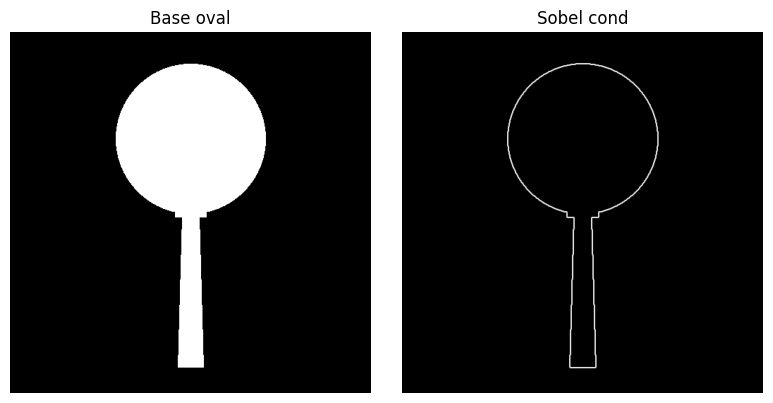

In [6]:
base_image_pil, base_tensor = build_base_image(device)
with torch.no_grad():
    sobel_pil = T.ToPILImage()(sobel_proxy(base_tensor, device).squeeze(0).cpu())

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(base_image_pil); axes[0].set_title('Base oval');   axes[0].axis('off')
axes[1].imshow(sobel_pil, cmap='gray'); axes[1].set_title('Sobel cond'); axes[1].axis('off')
plt.tight_layout(); display(fig); plt.close()

## 7. Main experiment loop

For each seed we: generate source portraits → extract scribbles (man / woman / avg / sdedit) → draw a fresh target → generate `N_COND` neutral images per condition → compute MMD and save everything.

In [7]:
import os
SAVE_DIR = '/content/scribble_runs'
os.makedirs(SAVE_DIR, exist_ok=True)

all_records = []   # one dict per (seed, condition)

# best_per_method[cond] = {'seed': int, 'mmd': float, 'scribble': PIL}
best_per_method = {c: {'seed': None, 'mmd': float('inf'), 'scribble': None} for c in CONDITION_NAMES}

for seed in range(1, N_RUNS + 1):
    print(f"\n{'='*55}")
    print(f'  SEED {seed}/{N_RUNS}')
    print(f"{'='*55}")

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

    # ── Source portraits
    with torch.no_grad():
        man_imgs, _   = generate_and_store_cs(sprinter, MAN_PROMPT,   sobel_pil, N_SOURCE, 2, CONTROLNET_SCALE, seed=seed)
        woman_imgs, _ = generate_and_store_cs(sprinter, WOMAN_PROMPT, sobel_pil, N_SOURCE, 2, CONTROLNET_SCALE, seed=seed + 1)

    src_man, src_woman = man_imgs[0], woman_imgs[0]

    # ── HED scribbles
    scr_man   = hed(src_man,   scribble=True)
    scr_woman = hed(src_woman, scribble=True)
    avg_np    = ((np.array(scr_man).astype(np.float32) + np.array(scr_woman).astype(np.float32)) / 2.0).clip(0, 255).astype(np.uint8)
    scr_avg   = Image.fromarray(avg_np)
    scr_sdedit = run_sdedit(scr_man, seed)

    # ── Save scribbles
    seed_dir = os.path.join(SAVE_DIR, f'seed_{seed:02d}')
    os.makedirs(seed_dir, exist_ok=True)
    scr_man.save(   os.path.join(seed_dir, 'scribble_man.png'))
    scr_woman.save( os.path.join(seed_dir, 'scribble_woman.png'))
    scr_avg.save(   os.path.join(seed_dir, 'scribble_avg.png'))
    scr_sdedit.save(os.path.join(seed_dir, 'scribble_sdedit.png'))

    run_conditions = {
        'man_scribble':    scr_man,
        'woman_scribble':  scr_woman,
        'avg_scribble':    scr_avg,
        'sdedit_scribble': scr_sdedit,
    }

    # ── Fresh target distribution for this seed
    print('  Building target distribution...')
    proxy_target_clip = build_target(sobel_pil, seed_offset=seed * 1000, n=N_COND)

    # ── Evaluate each condition
    seed_results = {}
    for cond_name, scribble in run_conditions.items():
        print(f'  Generating [{cond_name}]...')
        imgs = generate_condition(scribble, NEUTRAL_PROMPT, N_COND, seed=seed)
        embs = clip_embed(imgs)
        mmd  = compute_mmd(embs, proxy_target_clip.detach()).item()

        # Gender classification
        softmax_res, _ = compute_clip_softmax(imgs, clip_model, clip_processor, MAN_PROMPT, WOMAN_PROMPT, device)
        n_male   = sum(1 for r in softmax_res if r['label'] == 'male')
        pct_male = n_male / len(softmax_res) * 100

        record = {'seed': seed, 'condition': cond_name, 'mmd': mmd, 'pct_male': pct_male}
        all_records.append(record)
        seed_results[cond_name] = mmd

        print(f'    MMD={mmd:.5f}  male={pct_male:.1f}%')

        # Track best scribble per method
        if mmd < best_per_method[cond_name]['mmd']:
            best_per_method[cond_name]['mmd']     = mmd
            best_per_method[cond_name]['seed']    = seed
            best_per_method[cond_name]['scribble'] = scribble.copy()

    # Save per-seed results
    with open(os.path.join(seed_dir, 'results.json'), 'w') as f:
        json.dump(seed_results, f, indent=2)

print('\nAll runs complete.')


  SEED 1/10


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/controlnet/pipeline_controlnet_sd_xl.py:928: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  10/10
  10/10
  Building target distribution...
  125/125
  125/125
  Generating [man_scribble]...
  250/250
  [softmax] text_features shape: torch.Size([2, 768])  dtype: torch.float32
    MMD=0.50092  male=84.4%
  Generating [woman_scribble]...
  250/250
  [softmax] text_features shape: torch.Size([2, 768])  dtype: torch.float32
    MMD=0.68314  male=0.0%
  Generating [avg_scribble]...
  250/250
  [softmax] text_features shape: torch.Size([2, 768])  dtype: torch.float32
    MMD=0.47941  male=14.4%
  Generating [sdedit_scribble]...
  250/250
  [softmax] text_features shape: torch.Size([2, 768])  dtype: torch.float32
    MMD=0.44993  male=86.8%

  SEED 2/10
  10/10
  10/10
  Building target distribution...
  125/125
  125/125
  Generating [man_scribble]...
  250/250
  [softmax] text_features shape: torch.Size([2, 768])  dtype: torch.float32
    MMD=0.47409  male=63.2%
  Generating [woman_scribble]...
  250/250
  [softmax] text_features shape: torch.Size([2, 768])  dtype: torch.float32

## 8. Save best scribbles

The best scribble per method (lowest per-run MMD) is saved to disk.

Best scribble summary (by per-run MMD proxy):
  man_scribble          seed=5  proxy_mmd=0.44067  saved → /content/scribble_runs/best_scribbles/best_man_scribble.png
  woman_scribble        seed=6  proxy_mmd=0.57887  saved → /content/scribble_runs/best_scribbles/best_woman_scribble.png
  avg_scribble          seed=7  proxy_mmd=0.46210  saved → /content/scribble_runs/best_scribbles/best_avg_scribble.png
  sdedit_scribble       seed=2  proxy_mmd=0.42361  saved → /content/scribble_runs/best_scribbles/best_sdedit_scribble.png


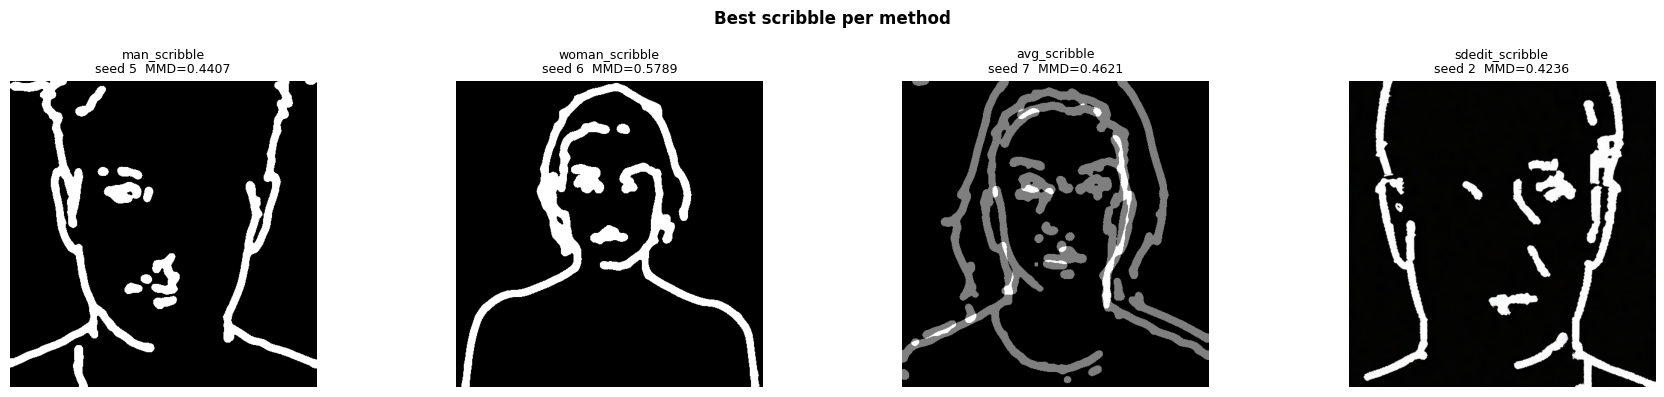

In [8]:
BEST_DIR = os.path.join(SAVE_DIR, 'best_scribbles')
os.makedirs(BEST_DIR, exist_ok=True)

print('Best scribble summary (by per-run MMD proxy):')
for cond, info in best_per_method.items():
    path = os.path.join(BEST_DIR, f'best_{cond}.png')
    info['scribble'].save(path)
    print(f'  {cond:<20}  seed={info["seed"]}  proxy_mmd={info["mmd"]:.5f}  saved → {path}')

# Visualise best scribbles
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, cond in zip(axes, CONDITION_NAMES):
    ax.imshow(best_per_method[cond]['scribble'], cmap='gray')
    ax.set_title(f'{cond}\nseed {best_per_method[cond]["seed"]}  MMD={best_per_method[cond]["mmd"]:.4f}', fontsize=9)
    ax.axis('off')
plt.suptitle('Best scribble per method', fontsize=12, fontweight='bold')
plt.tight_layout(); display(fig); plt.close()

## 9. Final evaluation on best scribbles

For each method's best scribble:
- Generate **2 000** images with the neutral prompt.
- Build a fresh target distribution of **2 000** images (1 000 man + 1 000 woman).
- Compute MMD in CLIP space.
- Classify images by gender (CLIP softmax) and compute a 95 % CI for *p*(male) via normal approximation.

In [9]:
from metrics import compute_swd

FINAL_SEED = 9999   # fixed seed for reproducible final evaluation

print(f'Building final target distribution ({N_TARGET} images)...')
final_target_clip = build_target(sobel_pil, seed_offset=FINAL_SEED)
print(f'Target CLIP embeddings: {final_target_clip.shape}')

final_results = {}

for cond in CONDITION_NAMES:
    best_scribble = best_per_method[cond]['scribble']
    print(f'\n[{cond}]  generating {N_FINAL} images...')

    imgs = generate_condition(best_scribble, NEUTRAL_PROMPT, N_FINAL, seed=FINAL_SEED)

    # CLIP embeddings + MMD
    embs = clip_embed(imgs)
    mmd  = compute_mmd(embs, final_target_clip.detach()).item()

    # SWD
    swd  = compute_swd(embs, final_target_clip.detach()).item()

    # Gender classification
    softmax_res, _ = compute_clip_softmax(imgs, clip_model, clip_processor, MAN_PROMPT, WOMAN_PROMPT, device)
    n_male = sum(1 for r in softmax_res if r['label'] == 'male')

    p_hat, ci_lo, ci_hi = binomial_ci_normal(n_male, N_FINAL)

    final_results[cond] = {
        'mmd':      mmd,
        'swd':      swd,
        'n_male':   n_male,
        'n_female': N_FINAL - n_male,
        'p_male':   p_hat,
        'ci_lo':    ci_lo,
        'ci_hi':    ci_hi,
        'best_seed': best_per_method[cond]['seed'],
    }

    print(f'  MMD={mmd:.5f}  SWD={swd:.5f}  p(male)={p_hat:.3f}  95%CI=[{ci_lo:.3f}, {ci_hi:.3f}]  ({n_male}M / {N_FINAL - n_male}F)')

print('\nFinal evaluation complete.')

Building final target distribution (2000 images)...
  1000/1000
  1000/1000
Target CLIP embeddings: torch.Size([2000, 768])

[man_scribble]  generating 2000 images...
  2000/2000
      [SWD] n_proj=20  swd=0.008725  delta=0.001176
      [SWD] n_proj=30  swd=0.009889  delta=0.001164
      [SWD] n_proj=40  swd=0.012849  delta=0.002960
      [SWD] n_proj=50  swd=0.011970  delta=0.000880
      [SWD] Converged at n_projections=50
  [softmax] text_features shape: torch.Size([2, 768])  dtype: torch.float32
  MMD=0.44496  SWD=0.01197  p(male)=0.611  95%CI=[0.590, 0.632]  (1222M / 778F)

[woman_scribble]  generating 2000 images...
  2000/2000
      [SWD] n_proj=20  swd=0.019671  delta=0.007580
      [SWD] n_proj=30  swd=0.019642  delta=0.000029
      [SWD] Converged at n_projections=30
  [softmax] text_features shape: torch.Size([2, 768])  dtype: torch.float32
  MMD=0.55336  SWD=0.01964  p(male)=0.001  95%CI=[-0.000, 0.001]  (1M / 1999F)

[avg_scribble]  generating 2000 images...
  2000/2000
  

## 10. Results summary

In [13]:
import pandas as pd

def agg(vals):
    a = np.array([v for v in vals if not np.isnan(v)])
    return f'{a.mean():.4f} ± {a.std():.4f}' if len(a) else '—'

# ── Per-run aggregation table (no SWD — not recorded per run)
run_rows = {}
for cond in CONDITION_NAMES:
    recs = [r for r in all_records if r['condition'] == cond]
    run_rows[cond] = {
        'MMD (mean ± std)':   agg([r['mmd']      for r in recs]),
        '% male (mean ± std)': agg([r['pct_male'] for r in recs]),
    }
print('=== Per-run summary (N_COND images/seed) ===')
display(pd.DataFrame(run_rows).T)

# ── Final evaluation table (has SWD)
final_rows = {}
for cond, r in final_results.items():
    final_rows[cond] = {
        'Best seed':   r['best_seed'],
        'MMD (final)': f"{r['mmd']:.5f}",
        'SWD (final)': f"{r['swd']:.5f}",
        'n male':      r['n_male'],
        'n female':    r['n_female'],
        'p(male)':     f"{r['p_male']:.3f}",
        '95% CI':      f"[{r['ci_lo']:.3f}, {r['ci_hi']:.3f}]",
    }
print('\n=== Final evaluation (N_FINAL images from best scribble) ===')
display(pd.DataFrame(final_rows).T)

=== Per-run summary (N_COND images/seed) ===


,MMD (mean ± std),% male (mean ± std)
man_scribble,0.5171 ± 0.0457,87.7600 ± 14.2988
woman_scribble,0.6391 ± 0.0409,0.0000 ± 0.0000
avg_scribble,0.5190 ± 0.0301,11.4800 ± 11.5184
sdedit_scribble,0.4688 ± 0.0416,75.4000 ± 18.2842



=== Final evaluation (N_FINAL images from best scribble) ===


,Best seed,MMD (final),SWD (final),n male,n female,p(male),95% CI
man_scribble,5,0.44496,0.01197,1222,778,0.611,"[0.590, 0.632]"
woman_scribble,6,0.55336,0.01964,1,1999,0.001,"[-0.000, 0.001]"
avg_scribble,7,0.43506,0.01053,141,1859,0.070,"[0.059, 0.082]"
sdedit_scribble,2,0.40932,0.00818,964,1036,0.482,"[0.460, 0.504]"


## 11. Visualisation

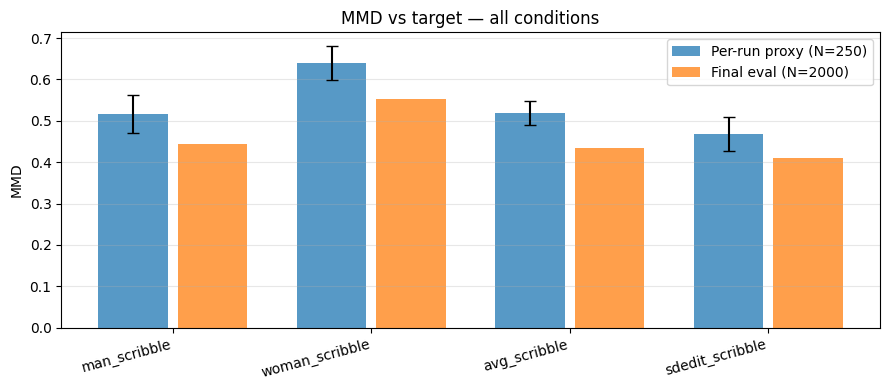

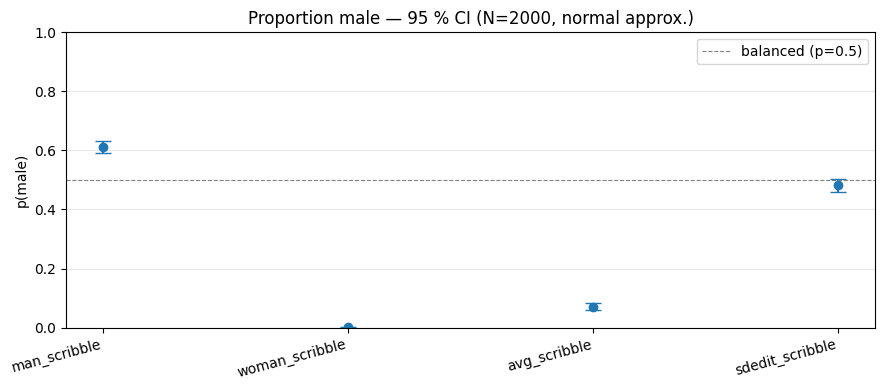

In [14]:
# ── MMD bar chart with per-run error bars
means = [np.mean([r['mmd'] for r in all_records if r['condition'] == c]) for c in CONDITION_NAMES]
stds  = [np.std( [r['mmd'] for r in all_records if r['condition'] == c]) for c in CONDITION_NAMES]
final_mmds = [final_results[c]['mmd'] for c in CONDITION_NAMES]

x = np.arange(len(CONDITION_NAMES))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - 0.2, means,       0.35, yerr=stds, capsize=4, alpha=0.75, label=f'Per-run proxy (N={N_COND})')
ax.bar(x + 0.2, final_mmds,  0.35, alpha=0.75, label=f'Final eval (N={N_FINAL})')
ax.set_xticks(x); ax.set_xticklabels(CONDITION_NAMES, rotation=15, ha='right')
ax.set_ylabel('MMD'); ax.set_title('MMD vs target — all conditions')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); display(fig); plt.close()

# ── p(male) CI plot
p_hats = [final_results[c]['p_male'] for c in CONDITION_NAMES]
ci_lo  = [final_results[c]['ci_lo']  for c in CONDITION_NAMES]
ci_hi  = [final_results[c]['ci_hi']  for c in CONDITION_NAMES]
errors = [[p - lo for p, lo in zip(p_hats, ci_lo)],
          [hi - p for p, hi in zip(p_hats, ci_hi)]]

fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(CONDITION_NAMES, p_hats, yerr=errors, fmt='o', capsize=6, linewidth=1.5)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='balanced (p=0.5)')
ax.set_ylabel('p(male)')
ax.set_title(f'Proportion male — 95 % CI (N={N_FINAL}, normal approx.)')
ax.set_ylim(0, 1); ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); display(fig); plt.close()

## 12. Save results & download

In [15]:
import shutil

# ── Save JSON results
with open(os.path.join(SAVE_DIR, 'all_run_records.json'), 'w') as f:
    json.dump(all_records, f, indent=2)

with open(os.path.join(SAVE_DIR, 'final_results.json'), 'w') as f:
    json.dump(final_results, f, indent=2)

print(f'Results saved to {SAVE_DIR}')

# ── Zip and download
zip_path = '/content/scribble_runs_backup'
shutil.make_archive(zip_path, 'zip', SAVE_DIR)
print(f'Archive: {zip_path}.zip')

from google.colab import files
files.download(f'{zip_path}.zip')

Results saved to /content/scribble_runs
Archive: /content/scribble_runs_backup.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>